# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [7]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.window import Window

# 1. Volvemos a encender el cerebro de Spark
spark = SparkSession.builder \
    .appName("ProyectoIoT") \
    .getOrCreate()

# 2. Recuperamos los datos guardados del disco
# (Si esto falla, es que se borraron los archivos al reiniciar y toca generar de nuevo)
try:
    df_final = spark.read.parquet("resultados/")
    print("✅ ¡Datos recuperados! Ya puedes seguir con los ejercicios.")
    print(f"Filas cargadas: {df_final.count()}")
except Exception as e:
    print("⚠️ ¡OJO! No encuentro los datos guardados.")
    print("Tendrás que volver a ejecutar el Producer y la celda de Streaming unos minutos.")

✅ ¡Datos recuperados! Ya puedes seguir con los ejercicios.
Filas cargadas: 605


In [8]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [9]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [10]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [11]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [12]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [14]:
# --- PASO OBLIGATORIO: CARGAR DATOS ---
# Leemos la carpeta donde el streaming ha estado guardando cosas
df_final = spark.read.parquet("resultados/")

# Comprobamos que funciona
print("¡Datos cargados!")

¡Datos cargados!


### Ejercicio 1

In [15]:
print("--- Esquema ---")
df_final.printSchema()

print(f"Total de filas: {df_final.count()}")

num_sensors = df_final.select("sensor_id").distinct().count()
print(f"Sensores distintos: {num_sensors}")

--- Esquema ---
root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)

Total de filas: 122
Sensores distintos: 4


### Ejercicio 2

In [16]:
from pyspark.sql.functions import col, min, max, avg

# --- Ejercicio 2: Transformaciones numéricas ---

# 1. Crear una nueva columna (Ratio Temperatura / Humedad)
df_trans = df_final.withColumn("temp_hum_ratio", col("avg_temp") / col("avg_humidity"))

# 2. Calcular Mínimo, Máximo y Media de esa nueva columna
print("--- Estadísticas del Ratio Temp/Humedad ---")
df_trans.select(
    min("temp_hum_ratio").alias("Minimo"),
    max("temp_hum_ratio").alias("Maximo"),
    avg("temp_hum_ratio").alias("Media")
).show()

--- Estadísticas del Ratio Temp/Humedad ---
+------------------+------------------+------------------+
|            Minimo|            Maximo|             Media|
+------------------+------------------+------------------+
|0.3008457511075312|2.2320813514843367|0.9834832222148919|
+------------------+------------------+------------------+



### Ejercicio 3

In [4]:
from pyspark.sql.functions import col

# --- Ejercicio 3: Filtrado avanzado  ---

df_filtered = df_final.filter(
    (col("avg_humidity") > 0) & 
    (col("num_events") >= 1) & 
    (col("sensor_id").isNotNull()) 
)

# Contamos de nuevo
count_filtered = df_filtered.count()

print(f"Registros que cumplen las nuevas condiciones: {count_filtered}")

# Mostramos los primeros 5 para que veas que ahora sí hay "chicha"
print("Muestra de los registros filtrados:")
df_filtered.show(5, truncate=False)

Registros que cumplen las nuevas condiciones: 605
Muestra de los registros filtrados:
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|window                                    |sensor_id|avg_value         |avg_temp          |avg_humidity     |num_events|
+------------------------------------------+---------+------------------+------------------+-----------------+----------+
|{2026-02-04 17:17:00, 2026-02-04 17:17:30}|S2       |33.893333333333324|56.451666666666675|51.93            |6         |
|{2026-02-04 17:17:00, 2026-02-04 17:17:30}|S3       |29.24875          |63.87             |52.705           |8         |
|{2026-02-04 17:22:00, 2026-02-04 17:22:30}|S1       |27.659999999999997|62.10166666666667 |59.34916666666667|12        |
|{2026-02-04 17:22:00, 2026-02-04 17:22:30}|S4       |32.69090909090909 |58.91909090909092 |55.77909090909091|11        |
|{2026-02-04 22:34:30, 2026-02-04 22:35:00}|S3       |38.449

### Ejercicio 4

In [5]:
from pyspark.sql.functions import avg, max, count, desc

print("--- Ejercicio 4: Agregaciones ---")

# Agrupamos por sensor y calculamos las métricas
stats_df = df_final.groupBy("sensor_id").agg(
    avg("avg_value").alias("media_valor"),
    max("avg_temp").alias("max_temp"),
    count("*").alias("total_ventanas")
)

# 1. ¿Qué sensor tiene la mayor media?
print("Sensor con mayor media de valor:")
stats_df.orderBy(desc("media_valor")).show(1)

# 2. ¿Qué sensor presenta la temperatura máxima?
print("Sensor con temperatura máxima:")
stats_df.orderBy(desc("max_temp")).show(1)

# 3. ¿Cuántos grupos existen por sensor?
print("Resumen por sensor:")
stats_df.show()

--- Ejercicio 4: Agregaciones ---
Sensor con mayor media de valor:
+---------+------------------+-----------------+--------------+
|sensor_id|       media_valor|         max_temp|total_ventanas|
+---------+------------------+-----------------+--------------+
|       S2|30.821297183927182|79.25166666666667|           150|
+---------+------------------+-----------------+--------------+
only showing top 1 row

Sensor con temperatura máxima:
+---------+------------------+--------+--------------+
|sensor_id|       media_valor|max_temp|total_ventanas|
+---------+------------------+--------+--------------+
|       S4|30.107449712722882|  86.675|           151|
+---------+------------------+--------+--------------+
only showing top 1 row

Resumen por sensor:
+---------+------------------+-----------------+--------------+
|sensor_id|       media_valor|         max_temp|total_ventanas|
+---------+------------------+-----------------+--------------+
|       S4|30.107449712722882|           86.675

### Ejercicio 5

In [6]:
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, col

print("--- Ejercicio 5: Ranking ---")

# Definimos la ventana: "Para cada sensor, ordena los datos por avg_value de mayor a menor"
windowSpec = Window.partitionBy("sensor_id").orderBy(col("avg_value").desc())

# Creamos el ranking (1 = el valor más alto, 2 = el segundo, etc.)
df_ranked = df_final.withColumn("rank", row_number().over(windowSpec))

# Nos quedamos solo con los "campeones" (rank = 1) de cada sensor
mejores_por_sensor = df_ranked.filter(col("rank") == 1)

print("Mejor registro de cada sensor:")
mejores_por_sensor.select("sensor_id", "avg_value", "avg_temp", "window").show(truncate=False)

# ¿Cuál es el máximo global?
print("Sensor con el valor MÁXIMO GLOBAL:")
mejores_por_sensor.orderBy(col("avg_value").desc()).show(1)

--- Ejercicio 5: Ranking ---
Mejor registro de cada sensor:
+---------+-----------------+------------------+------------------------------------------+
|sensor_id|avg_value        |avg_temp          |window                                    |
+---------+-----------------+------------------+------------------------------------------+
|S1       |43.835           |60.97166666666667 |{2026-02-04 22:46:30, 2026-02-04 22:47:00}|
|S2       |48.805           |78.43             |{2026-02-04 22:32:30, 2026-02-04 22:33:00}|
|S3       |41.43333333333334|42.526666666666664|{2026-02-04 22:21:30, 2026-02-04 22:22:00}|
|S4       |45.23            |64.87666666666667 |{2026-02-04 22:17:00, 2026-02-04 22:17:30}|
+---------+-----------------+------------------+------------------------------------------+

Sensor con el valor MÁXIMO GLOBAL:
+--------------------+---------+---------+--------+------------+----------+----+
|              window|sensor_id|avg_value|avg_temp|avg_humidity|num_events|rank|
+-----

### Ejercicio 6

In [7]:
print("--- Ejercicio 6: Join ---")

# 1. Creamos un DataFrame auxiliar "de mentira"
datos_aux = [
    ("sensor-1", "Zona Norte", "Tipo A"), 
    ("sensor-2", "Zona Sur", "Tipo B"),
    ("sensor-3", "Almacen", "Tipo A"),
    ("sensor-4", "Oficina", "Tipo C")
]
# Ajusta los IDs ("sensor-1", etc.) si ves que los tuyos se llaman diferente
cols_aux = ["sensor_id", "ubicacion", "tipo"]
df_aux = spark.createDataFrame(datos_aux, cols_aux)

# 2. Hacemos el Join (Left Join para no perder datos si no coinciden los IDs)
df_unido = df_final.join(df_aux, on="sensor_id", how="left")

print("Primeros 5 registros unidos:")
df_unido.select("sensor_id", "avg_value", "ubicacion", "tipo").show(5)

--- Ejercicio 6: Join ---
Primeros 5 registros unidos:
+---------+------------------+---------+----+
|sensor_id|         avg_value|ubicacion|tipo|
+---------+------------------+---------+----+
|       S4| 32.69090909090909|     NULL|NULL|
|       S4|             25.09|     NULL|NULL|
|       S3|          29.24875|     NULL|NULL|
|       S3|38.449999999999996|     NULL|NULL|
|       S2|33.893333333333324|     NULL|NULL|
+---------+------------------+---------+----+
only showing top 5 rows



### Ejercicio 7

In [8]:
from pyspark.sql.functions import date_format

print("--- Ejercicio 7: Agrupación Temporal ---")

# Extraemos el inicio de la ventana y lo truncamos a "minutos"
df_tiempo = df_final.withColumn("minuto", date_format(col("window.start"), "HH:mm"))

# Agrupamos por ese minuto
resumen_tiempo = df_tiempo.groupBy("minuto").agg(
    count("*").alias("num_ventanas"),
    avg("avg_humidity").alias("humedad_media")
).orderBy("minuto")

print("Resumen por minuto:")
resumen_tiempo.show()

--- Ejercicio 7: Agrupación Temporal ---
Resumen por minuto:
+------+------------+------------------+
|minuto|num_ventanas|     humedad_media|
+------+------------+------------------+
| 13:59|           7|58.321858974358975|
| 14:00|           4| 58.57745454545454|
| 14:52|           4|49.250750000000004|
| 14:53|           8| 55.14956398809523|
| 14:54|           8|54.241749999999996|
| 14:55|           8|52.739993551587304|
| 14:56|           8| 58.33537450396826|
| 14:57|           8| 59.40229017857142|
| 16:47|           3|             64.99|
| 17:12|           4|60.130133928571425|
| 17:13|           8| 56.31126736111111|
| 17:14|           8| 57.11652281746032|
| 17:15|           8|55.178444264069256|
| 17:16|           8| 64.97591071428572|
| 17:17|           8| 55.74065972222222|
| 17:18|           8|53.006728174603175|
| 17:19|           8| 58.00072668650794|
| 17:20|           8|56.586374007936506|
| 17:21|           8|53.511942640692645|
| 17:22|           8|57.3479071969696

### Ejercicio 8

In [9]:
from pyspark.sql.functions import spark_partition_id

print("--- Ejercicio 8: Particiones ---")

# Repartimos los datos en 2 particiones (o 4) basándonos en el sensor
df_repartido = df_final.repartition(2, "sensor_id")

# Añadimos una columna para chivarnos en qué partición cayó cada dato
df_repartido = df_repartido.withColumn("particion_id", spark_partition_id())

print("Distribución de registros por partición:")
df_repartido.groupBy("particion_id").count().show()

--- Ejercicio 8: Particiones ---
Distribución de registros por partición:
+------------+-----+
|particion_id|count|
+------------+-----+
|           0|  152|
|           1|  453|
+------------+-----+



### Ejercicio 9

In [10]:
print("--- Ejercicio 9: Anomalías ---")

# Definimos anomalía: Temperatura > 30 (ajusta este número si tus temps son más altas o bajas)
criterio_anomalia = col("avg_temp") > 30 

df_anomalos = df_final.filter(criterio_anomalia)

print(f"Total de anomalías detectadas: {df_anomalos.count()}")

print("Sensor más problemático (con más anomalías):")
df_anomalos.groupBy("sensor_id").count().orderBy(desc("count")).show(1)

--- Ejercicio 9: Anomalías ---
Total de anomalías detectadas: 601
Sensor más problemático (con más anomalías):
+---------+-----+
|sensor_id|count|
+---------+-----+
|       S1|  152|
+---------+-----+
only showing top 1 row



### Ejercicio 10

In [11]:
print("--- Ejercicio 10: Scoring ---")

# Fórmula mágica: 50% Valor + 25% Temperatura + 25% Humedad
df_score = df_final.withColumn("puntuacion_final", 
    (col("avg_value") * 0.5) + (col("avg_temp") * 0.25) + (col("avg_humidity") * 0.25)
)

print("Top 3 Sensores con mayor puntuación:")
df_score.select("sensor_id", "puntuacion_final").orderBy(desc("puntuacion_final")).show(3)

--- Ejercicio 10: Scoring ---
Top 3 Sensores con mayor puntuación:
+---------+-----------------+
|sensor_id| puntuacion_final|
+---------+-----------------+
|       S2|65.63125000000001|
|       S1|62.36750000000001|
|       S2|          55.1725|
+---------+-----------------+
only showing top 3 rows



### Ejercicio 11

--- Ejercicio 11: Gráficos ---


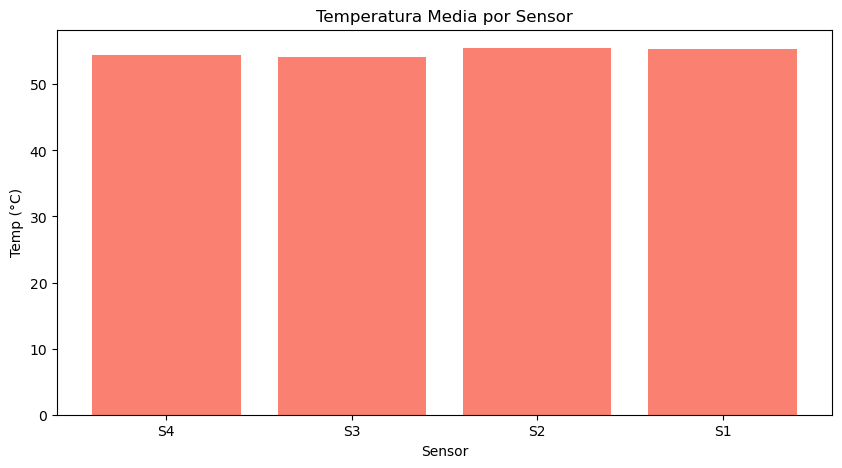

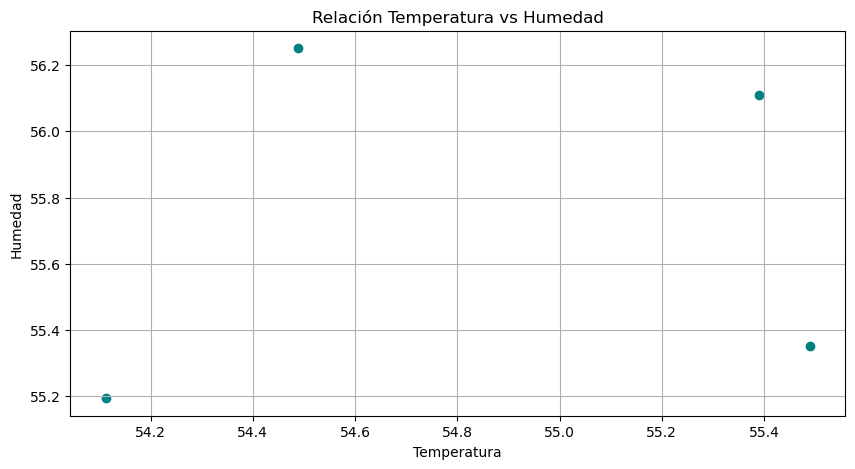

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

print("--- Ejercicio 11: Gráficos ---")

# 1. Agrupamos en Spark para reducir datos antes de pasar a Pandas
datos_grafico = df_final.groupBy("sensor_id").agg(
    avg("avg_temp").alias("temp_media"),
    avg("avg_humidity").alias("hum_media")
).toPandas()

# Gráfico 1: Barras de Temperatura
plt.figure(figsize=(10, 5))
plt.bar(datos_grafico["sensor_id"], datos_grafico["temp_media"], color='salmon')
plt.title("Temperatura Media por Sensor")
plt.xlabel("Sensor")
plt.ylabel("Temp (°C)")
plt.show()

# Gráfico 2: Dispersión (Scatter) Temp vs Humedad
plt.figure(figsize=(10, 5))
plt.scatter(datos_grafico["temp_media"], datos_grafico["hum_media"], color='teal')
plt.title("Relación Temperatura vs Humedad")
plt.xlabel("Temperatura")
plt.ylabel("Humedad")
plt.grid(True)
plt.show()